In [15]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import pandas as pd
from pathlib import Path

In [16]:
# ── Configuration — change COMMODITY here ──────────────────────────────────
COMMODITY = "Bulb Onions (Yellow)"   # options: Lettuce, Cabbage, Carrots, Bulb Onions (Yellow)
SAVE_PNG  = False        # set True to save a PNG instead of showing inline

In [35]:
BASE      = Path("../..").resolve()
PRED_DIR  = BASE / "outputs" / "predictions"
ARIMAX_DIR = BASE / "models" / "sarima_arimax" / "outputs" / "arimax" / "forecasts"
SARIMA_DIR = BASE / "models" / "sarima_arimax" / "outputs" / "sarima" / "forecasts"

COMMODITY_FILE_MAP = {
    "Bulb Onions (Yellow)": "Bulb_Onions_Yellow",
    "Cabbage":              "Cabbage",
    "Carrots":              "Carrots",
    "Lettuce":              "Lettuce",
}

MODEL_FILES = {
    "ARIMAX":  None,
    "SARIMA":  None,
    "TimeGPT": PRED_DIR / "timegpt_forecasts.csv",
    "S-Mamba": PRED_DIR / "smamba_forecasts.csv",
}

PALETTE = {
    "Actual":  "#2c3e50",
    "ARIMAX":  "#2980b9",
    "SARIMA":  "#8e44ad",
    "TimeGPT": "#e74c3c",
    "S-Mamba": "#16a085",
}

LINE_STYLES = {
    "Actual":  dict(linewidth=2.5, linestyle="-",             zorder=10),
    "ARIMAX":  dict(linewidth=1.8, linestyle="--"),
    "SARIMA":  dict(linewidth=1.8, linestyle="-."),
    "N-BEATS": dict(linewidth=1.8, linestyle=":"),
    "TimeGPT": dict(linewidth=1.8, linestyle=(0, (5, 1))),
    "Mamba":   dict(linewidth=1.8, linestyle=(0, (3, 1, 1, 1))),
    "S-Mamba": dict(linewidth=1.8, linestyle=(0, (1, 1))),
}

In [36]:
def load_arimax_sarima(commodity, model):
    stem = COMMODITY_FILE_MAP.get(commodity)
    if stem is None:
        return None
    folder = ARIMAX_DIR if model == "ARIMAX" else SARIMA_DIR
    path = folder / f"{stem}.csv"
    if not path.exists():
        return None
    df = pd.read_csv(path, parse_dates=["date"])
    df = df[df["commodity"].str.strip() == commodity][["date", "actual", "predicted"]].copy()
    df["model"] = model
    return df


def load_neural_model(model_name, commodity):
    path = MODEL_FILES[model_name]
    if path is None or not path.exists():
        return None
    df = pd.read_csv(path, parse_dates=["date"])
    df["commodity"] = df["commodity"].str.strip()
    sub = df[df["commodity"] == commodity][["date", "actual", "predicted"]].copy()
    if sub.empty:
        for m in df["commodity"].unique():
            if commodity.lower() in m.lower() or m.lower() in commodity.lower():
                sub = df[df["commodity"] == m][["date", "actual", "predicted"]].copy()
                break
    if sub.empty:
        return None
    sub["model"] = model_name
    return sub


def load_all(commodity):
    data = {}
    for model in MODEL_FILES:
        df = load_arimax_sarima(commodity, model) if model in ("ARIMAX", "SARIMA") \
             else load_neural_model(model, commodity)
        if df is not None and not df.empty:
            data[model] = df.sort_values("date").reset_index(drop=True)
    return data


def rmse(y_true, y_pred):
    return np.sqrt(np.mean((np.asarray(y_true) - np.asarray(y_pred)) ** 2))

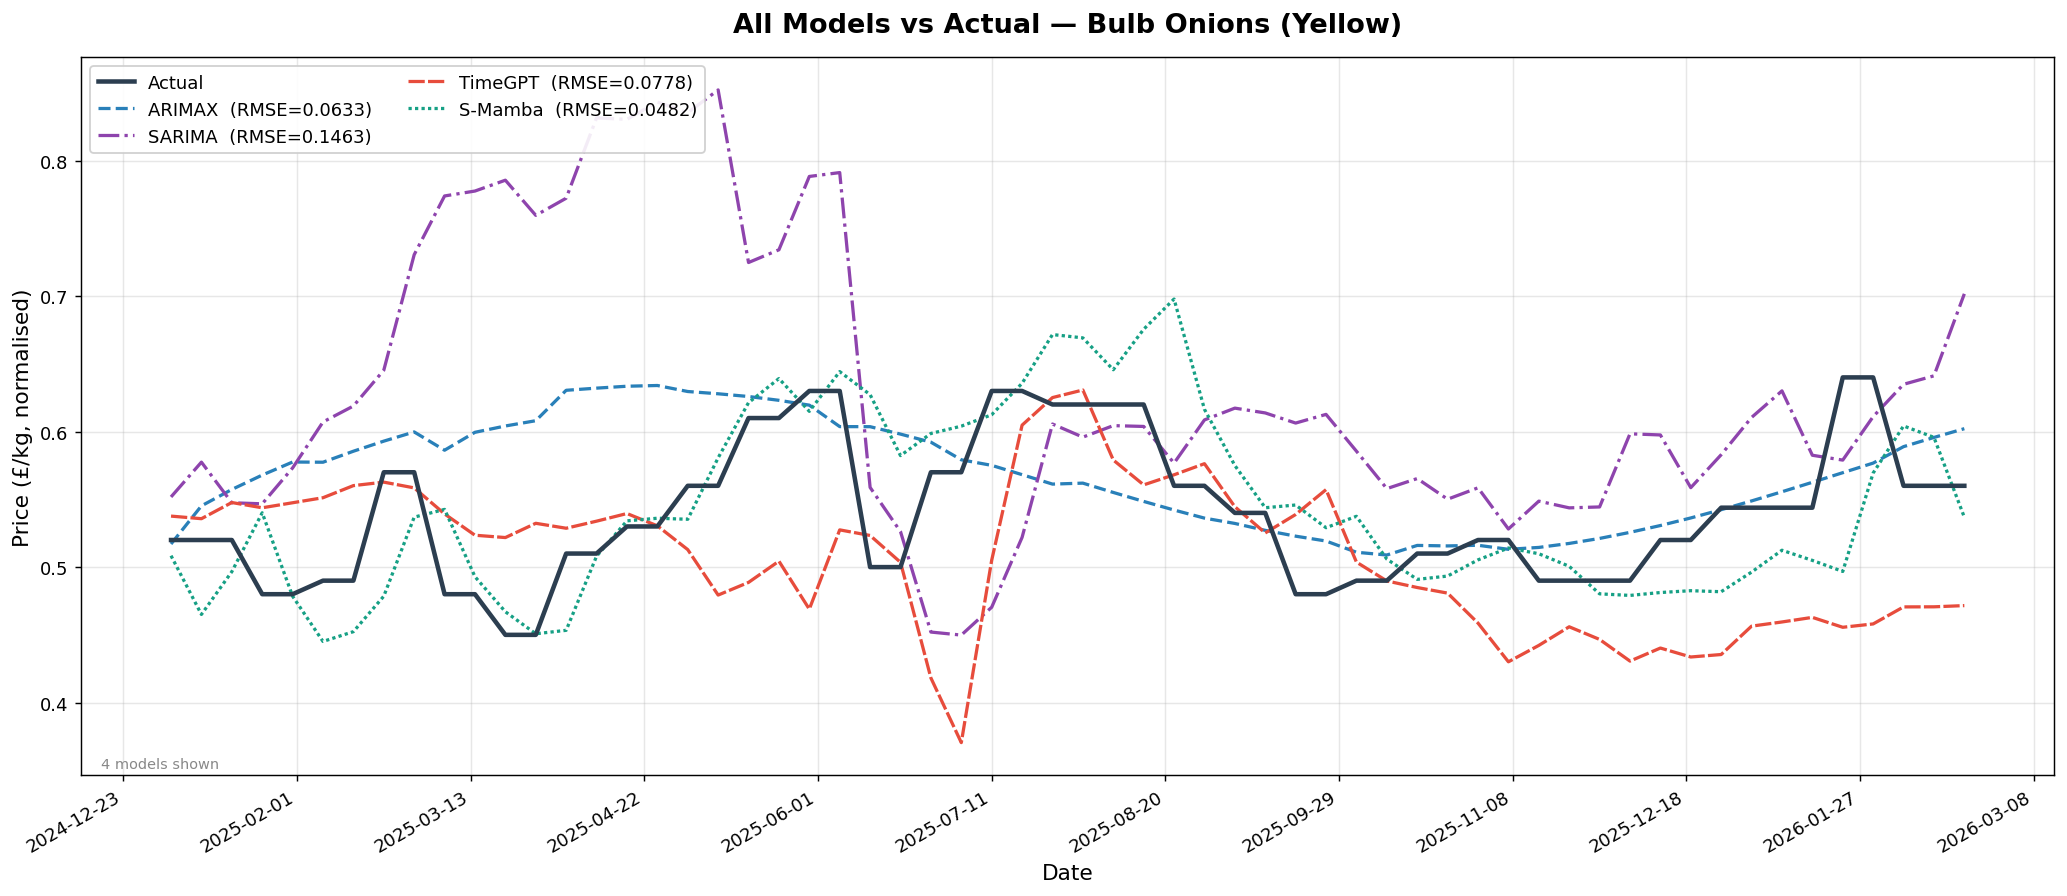


Models loaded: ['ARIMAX', 'SARIMA', 'TimeGPT', 'S-Mamba']


In [37]:
%matplotlib inline
plt.rcParams["figure.dpi"] = 130

data = load_all(COMMODITY)

if not data:
    print(f"No prediction files found for '{COMMODITY}'.")
    print(f"Files present: {[f.name for f in PRED_DIR.glob('*.csv')]}")
else:
    fig, ax = plt.subplots(figsize=(16, 7))

    # Actual line
    first = next(iter(data.values()))
    ax.plot(first["date"], first["actual"],
            color=PALETTE["Actual"], label="Actual", **LINE_STYLES["Actual"])

    for model, df in data.items():
        err = rmse(df["actual"], df["predicted"])
        ax.plot(df["date"], df["predicted"],
                color=PALETTE[model],
                label=f"{model}  (RMSE={err:.4f})",
                **LINE_STYLES[model])

    ax.set_title(f"All Models vs Actual — {COMMODITY}",
                 fontsize=15, fontweight="bold", pad=14)
    ax.set_xlabel("Date", fontsize=12)
    ax.set_ylabel("Price (£/kg, normalised)", fontsize=12)
    ax.xaxis.set_major_locator(ticker.MaxNLocator(12))
    fig.autofmt_xdate(rotation=30, ha="right")
    ax.legend(loc="upper left", fontsize=10, framealpha=0.9,
              edgecolor="#cccccc", ncol=2)
    ax.grid(True, alpha=0.3)

    missing = [m for m in MODEL_FILES if m not in data]
    ax.annotate(f"{len(data)} models shown" + (f"  |  missing: {', '.join(missing)}" if missing else ""),
                xy=(0.01, 0.01), xycoords="axes fraction", fontsize=8, color="#888888")

    plt.tight_layout()

    if SAVE_PNG:
        out = BASE / "outputs" / "model_comparison" / f"comparison_{COMMODITY.replace(' ', '_').replace('(','').replace(')','')}.png"
        fig.savefig(out, dpi=150, bbox_inches="tight")
        print(f"Saved → {out}")

    plt.show()
    print(f"\nModels loaded: {list(data.keys())}")
    if missing:
        print(f"Missing (not yet generated): {missing}")

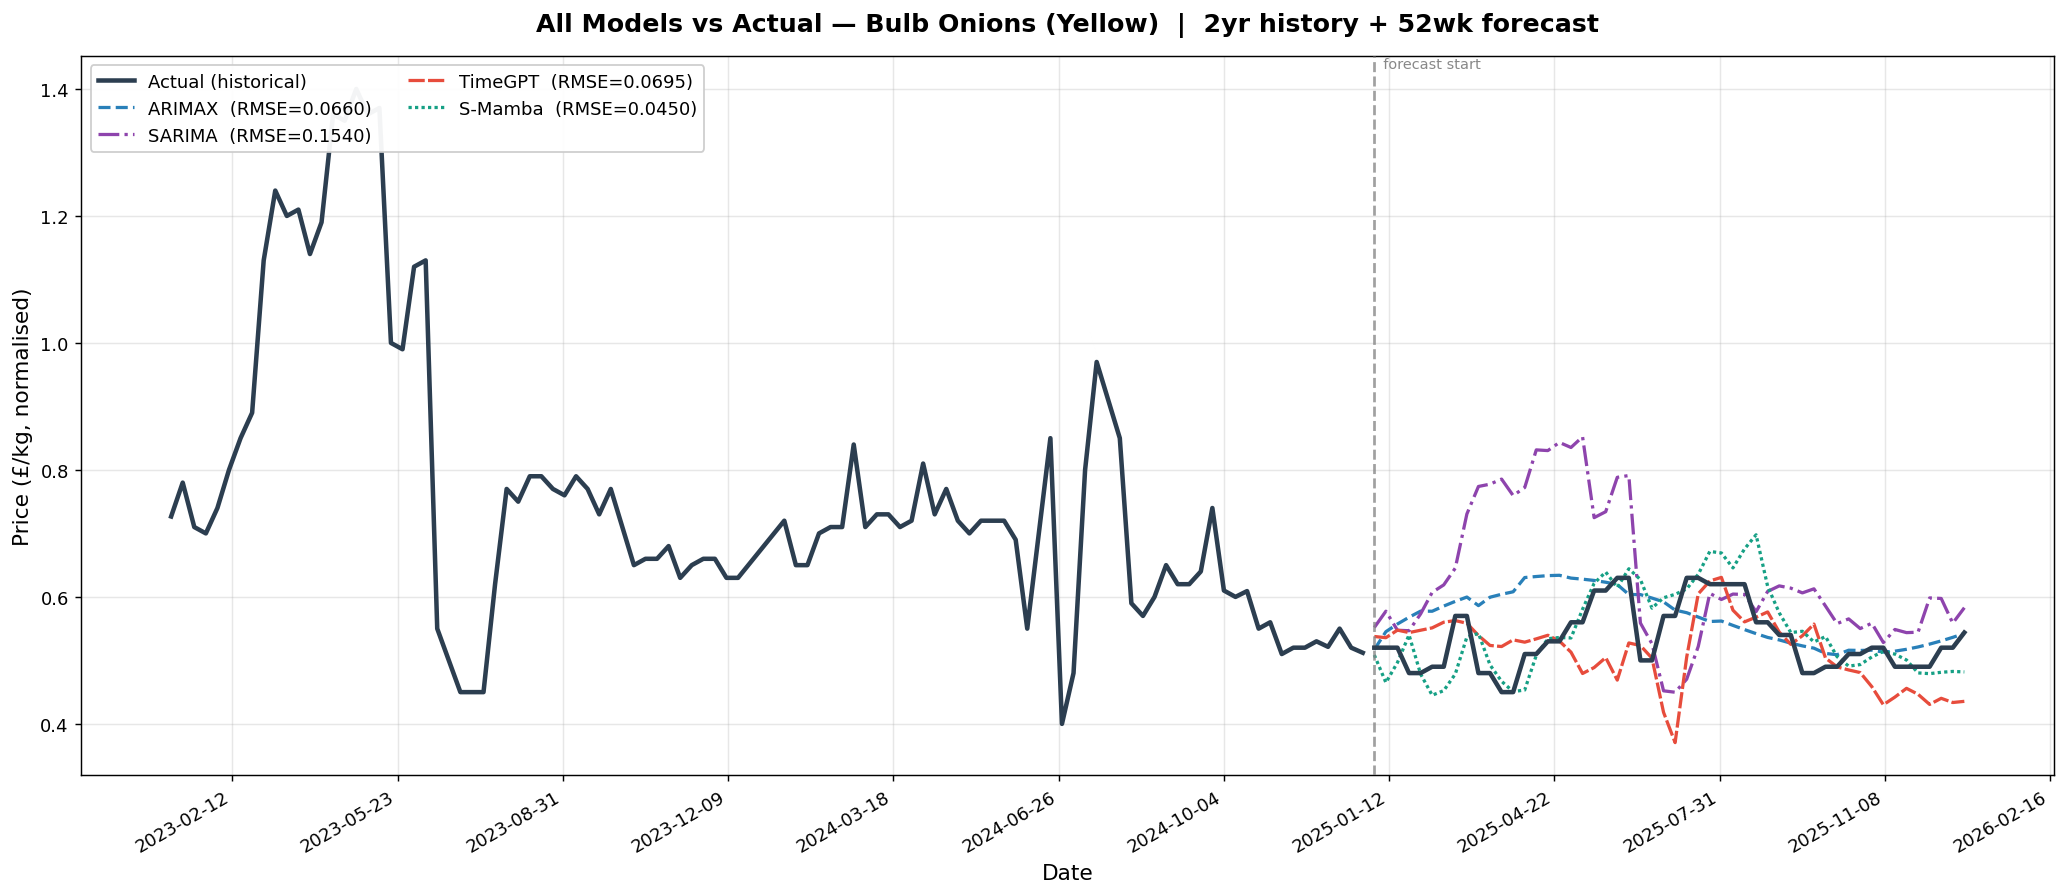

In [38]:

# ── Extended view: 2yr historical + 1yr forecast ────────────────────────────
HISTORY_YEARS  = 2
FORECAST_WEEKS = 52

# Load historical actuals from the parquet
parquet_path = BASE / "data" / "processed" / "merged_features_weekly.parquet"
df_hist_all  = pd.read_parquet(parquet_path)
df_hist_comm = (
    df_hist_all[df_hist_all["commodity"] == COMMODITY]
    .sort_values("date")
    .reset_index(drop=True)
)

data = load_all(COMMODITY)

if not data:
    print(f"No prediction files found for '{COMMODITY}'.")
else:
    first_pred_df  = next(iter(data.values()))
    forecast_start = pd.to_datetime(first_pred_df["date"].min())
    history_start  = forecast_start - pd.DateOffset(years=HISTORY_YEARS)
    forecast_end   = forecast_start + pd.DateOffset(weeks=FORECAST_WEEKS)

    hist = df_hist_comm[
        (pd.to_datetime(df_hist_comm["date"]) >= history_start) &
        (pd.to_datetime(df_hist_comm["date"]) <  forecast_start)
    ][["date", "target_price"]].copy()
    hist["date"] = pd.to_datetime(hist["date"])

    fig, ax = plt.subplots(figsize=(16, 7))

    # 2yr historical actual — solid line
    ax.plot(hist["date"], hist["target_price"],
            color=PALETTE["Actual"], linewidth=2.5, linestyle="-",
            label="Actual (historical)", zorder=10)

    # Vertical line at forecast cutoff
    ax.axvline(x=forecast_start, color="#888888", linestyle="--",
               linewidth=1.5, alpha=0.8, zorder=5)
    ax.text(forecast_start, ax.get_ylim()[1] if ax.get_ylim()[1] != 1 else 1,
            "  forecast start", fontsize=8, color="#888888", va="top")

    # 1yr model predictions
    for model, df in data.items():
        df_trim = df[pd.to_datetime(df["date"]) < forecast_end].copy()
        if df_trim.empty:
            continue
        err = rmse(df_trim["actual"], df_trim["predicted"])
        ax.plot(df_trim["date"], df_trim["predicted"],
                color=PALETTE[model],
                label=f"{model}  (RMSE={err:.4f})",
                **LINE_STYLES[model])

    # Actual test prices continuation
    actual_test = first_pred_df[pd.to_datetime(first_pred_df["date"]) < forecast_end]
    ax.plot(actual_test["date"], actual_test["actual"],
            color=PALETTE["Actual"], linewidth=2.5, linestyle="-", zorder=10)

    ax.set_title(f"All Models vs Actual — {COMMODITY}  |  {HISTORY_YEARS}yr history + {FORECAST_WEEKS}wk forecast",
                 fontsize=14, fontweight="bold", pad=14)
    ax.set_xlabel("Date", fontsize=12)
    ax.set_ylabel("Price (£/kg, normalised)", fontsize=12)
    ax.xaxis.set_major_locator(ticker.MaxNLocator(14))
    fig.autofmt_xdate(rotation=30, ha="right")

    legend = ax.legend(loc="upper left", fontsize=10, framealpha=0.95,
                       edgecolor="#cccccc", ncol=2)
    legend.set_zorder(20)   # bring legend in front of all lines

    ax.grid(True, alpha=0.3)

    missing = [m for m in MODEL_FILES if m not in data]
    if missing:
        ax.annotate(f"missing: {', '.join(missing)}",
                    xy=(0.01, 0.01), xycoords="axes fraction",
                    fontsize=8, color="#888888")

    plt.tight_layout()

    if SAVE_PNG:
        out = BASE / "outputs" / "model_comparison" / f"comparison_extended_{COMMODITY.replace(' ', '_').replace('(','').replace(')','')}.png"
        fig.savefig(out, dpi=150, bbox_inches="tight")
        print(f"Saved → {out}")

    plt.show()


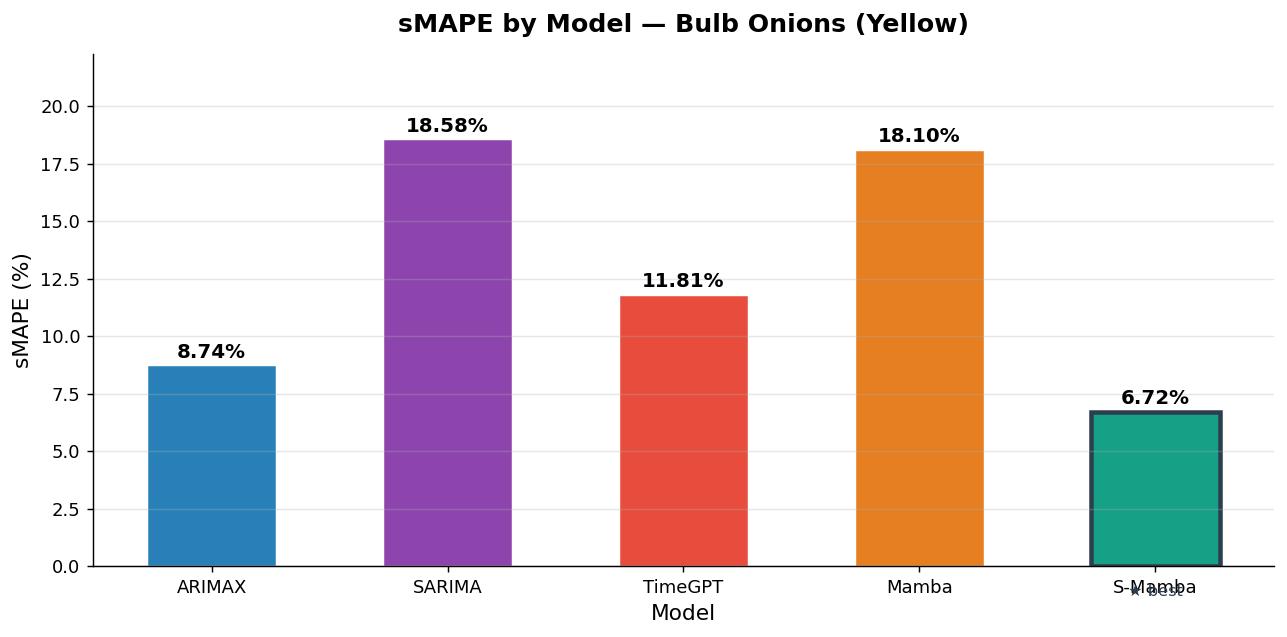


sMAPE ranking (Bulb Onions (Yellow)):
  1. S-Mamba    6.7227%
  2. ARIMAX     8.7388%
  3. TimeGPT    11.8120%
  4. Mamba      18.1040%
  5. SARIMA     18.5752%


In [20]:

# ── sMAPE comparison bar chart ─────────────────────────────────────────────
def smape(y_true, y_pred):
    a, p = np.asarray(y_true), np.asarray(y_pred)
    return np.mean(200 * np.abs(a - p) / (np.abs(a) + np.abs(p)))

if not data:
    print("No data loaded — run the cell above first.")
else:
    models  = list(data.keys())
    smapes  = [smape(df["actual"], df["predicted"]) for df in data.values()]
    colors  = [PALETTE[m] for m in models]

    fig, ax = plt.subplots(figsize=(10, 5))
    bars = ax.bar(models, smapes, color=colors, edgecolor="white", linewidth=0.8, width=0.55)

    # Value labels on top of each bar
    for bar, val in zip(bars, smapes):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.15,
                f"{val:.2f}%", ha="center", va="bottom", fontsize=11, fontweight="bold")

    ax.set_title(f"sMAPE by Model — {COMMODITY}",
                 fontsize=14, fontweight="bold", pad=12)
    ax.set_ylabel("sMAPE (%)", fontsize=12)
    ax.set_xlabel("Model", fontsize=12)
    ax.set_ylim(0, max(smapes) * 1.2)
    ax.grid(True, axis="y", alpha=0.3)
    ax.spines[["top", "right"]].set_visible(False)

    # Highlight best model
    best_idx = int(np.argmin(smapes))
    bars[best_idx].set_edgecolor("#2c3e50")
    bars[best_idx].set_linewidth(2.5)
    ax.text(bars[best_idx].get_x() + bars[best_idx].get_width() / 2,
            -max(smapes) * 0.07, "★ best", ha="center", fontsize=9, color="#2c3e50")

    plt.tight_layout()
    plt.show()

    print(f"\nsMAPE ranking ({COMMODITY}):")
    for rank, (m, s) in enumerate(sorted(zip(models, smapes), key=lambda x: x[1]), 1):
        print(f"  {rank}. {m:<10} {s:.4f}%")


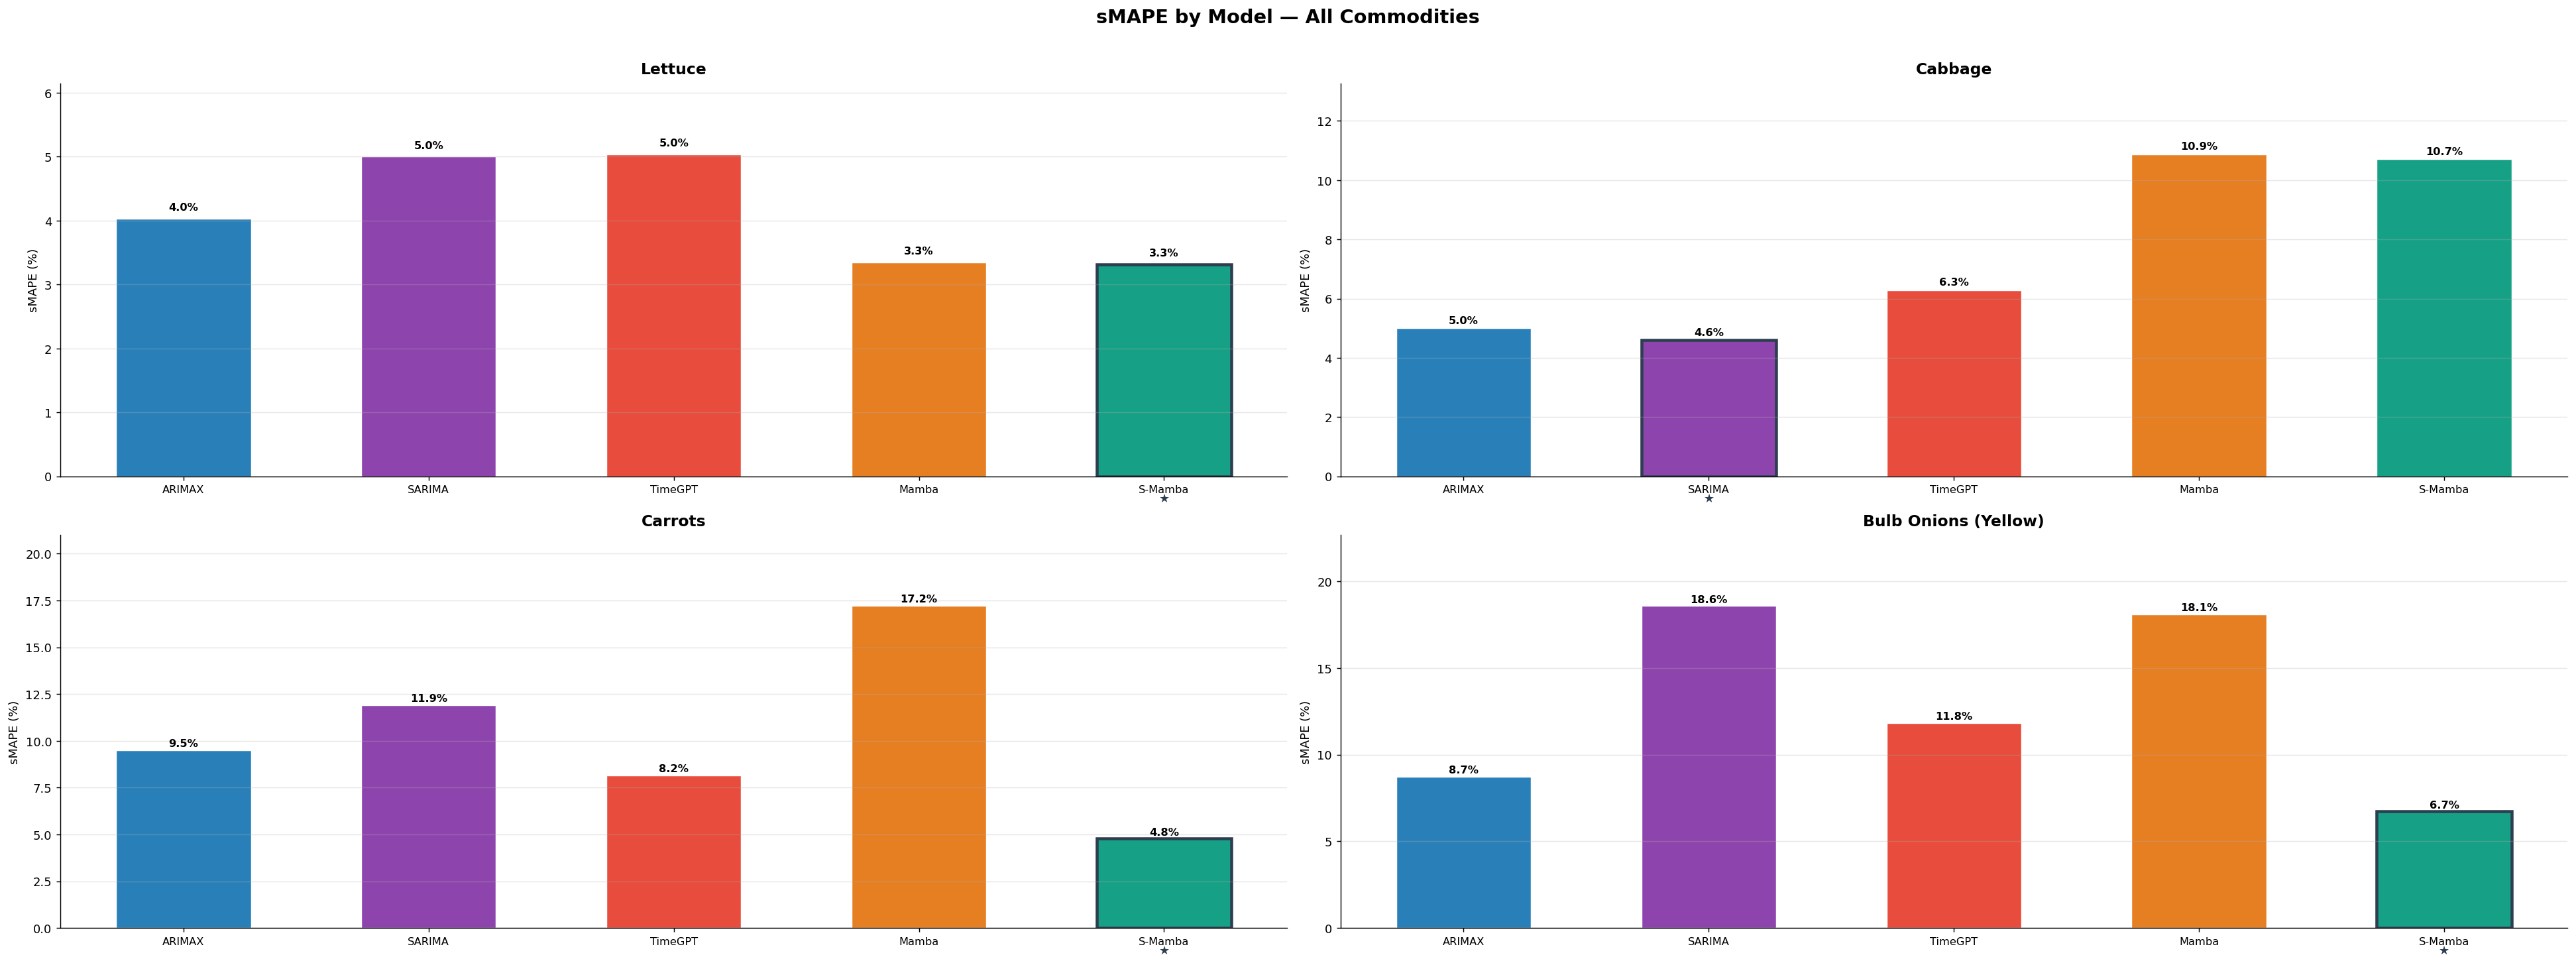

In [23]:

# ── sMAPE 2×2 matrix — all commodities ─────────────────────────────────────
ALL_COMMODITIES = ["Lettuce", "Cabbage", "Carrots", "Bulb Onions (Yellow)"]

fig, axes = plt.subplots(2, 2, figsize=(30, 11))
axes = axes.flatten()

for ax, comm in zip(axes, ALL_COMMODITIES):
    comm_data = load_all(comm)
    if not comm_data:
        ax.text(0.5, 0.5, f"No data\n{comm}", ha="center", va="center",
                transform=ax.transAxes, fontsize=12)
        ax.axis("off")
        continue

    models  = list(comm_data.keys())
    smapes  = [smape(df["actual"], df["predicted"]) for df in comm_data.values()]
    colors  = [PALETTE[m] for m in models]

    bars = ax.bar(models, smapes, color=colors, edgecolor="white", linewidth=0.8, width=0.55)

    for bar, val in zip(bars, smapes):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.1,
                f"{val:.1f}%", ha="center", va="bottom", fontsize=9, fontweight="bold")

    best_idx = int(np.argmin(smapes))
    bars[best_idx].set_edgecolor("#2c3e50")
    bars[best_idx].set_linewidth(2.5)
    ax.text(bars[best_idx].get_x() + bars[best_idx].get_width() / 2,
            -max(smapes) * 0.08, "★", ha="center", fontsize=10, color="#2c3e50")

    ax.set_title(comm, fontsize=13, fontweight="bold", pad=8)
    ax.set_ylabel("sMAPE (%)", fontsize=10)
    ax.set_ylim(0, max(smapes) * 1.22)
    ax.tick_params(axis="x", labelsize=9)
    ax.grid(True, axis="y", alpha=0.3)
    ax.spines[["top", "right"]].set_visible(False)

fig.suptitle("sMAPE by Model — All Commodities", fontsize=16, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()


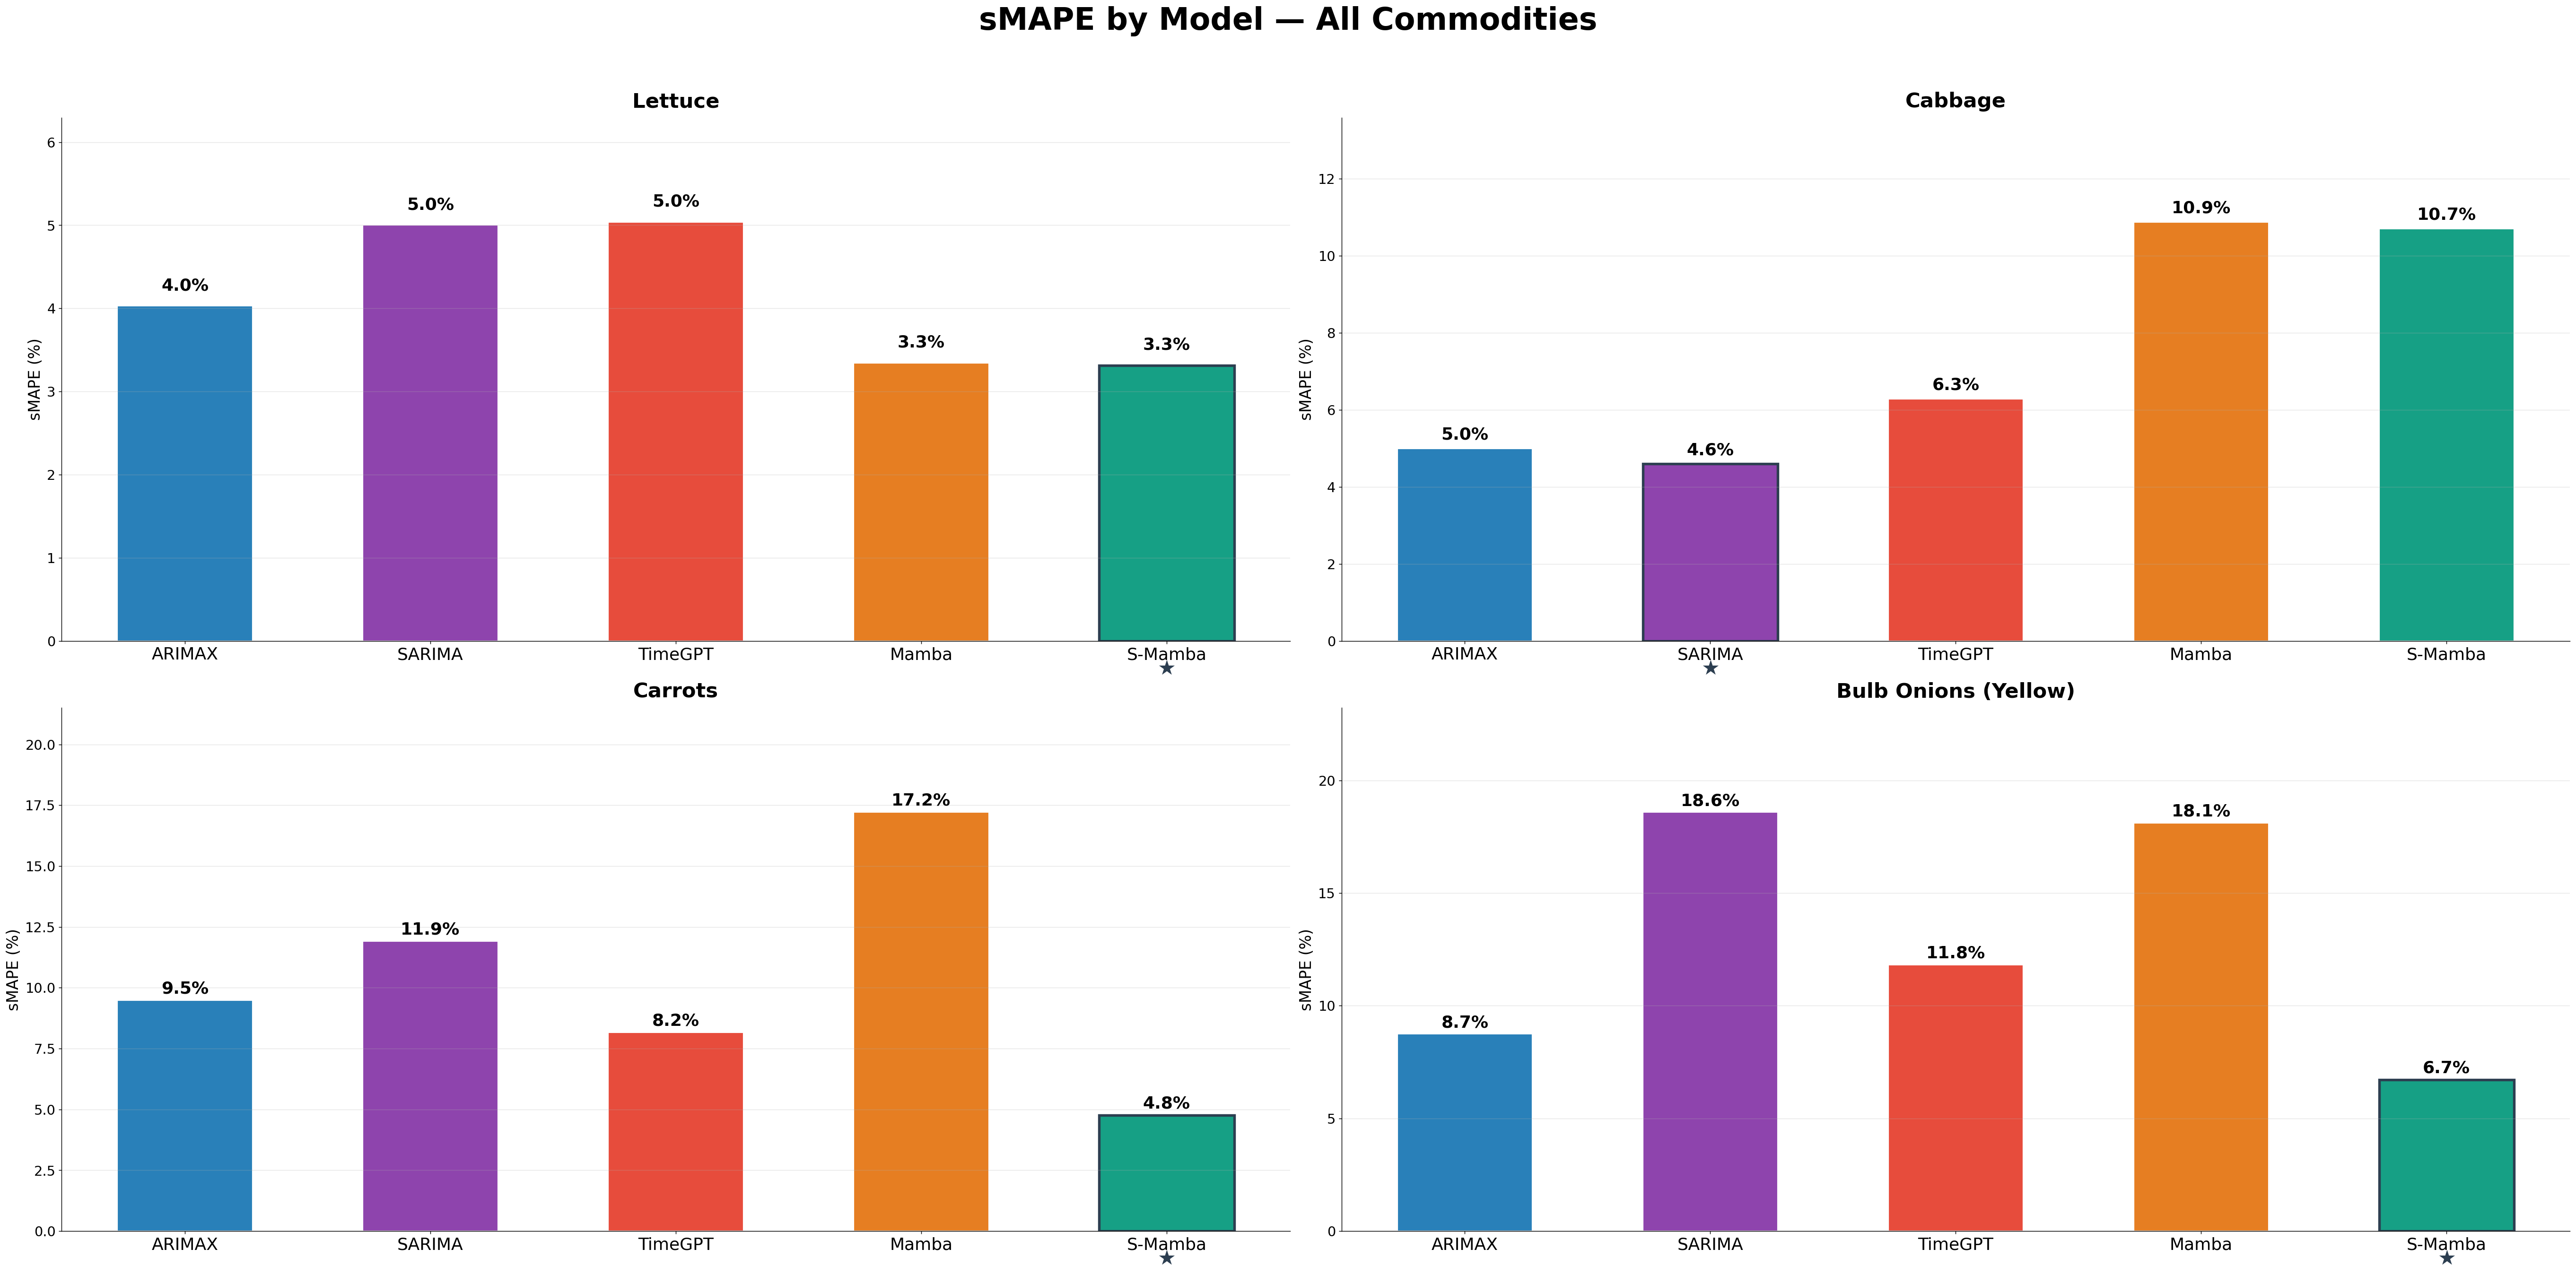

In [27]:
# ── sMAPE 2×2 matrix — all commodities ─────────────────────────────────────
ALL_COMMODITIES = ["Lettuce", "Cabbage", "Carrots", "Bulb Onions (Yellow)"]

fig, axes = plt.subplots(2, 2, figsize=(42, 20))   # wide for slides
axes = axes.flatten()

for ax, comm in zip(axes, ALL_COMMODITIES):

    comm_data = load_all(comm)

    if not comm_data:
        ax.text(0.5, 0.5, f"No data\n{comm}", ha="center", va="center",
                transform=ax.transAxes, fontsize=22)
        ax.axis("off")
        continue

    models = list(comm_data.keys())
    smapes = [smape(df["actual"], df["predicted"]) for df in comm_data.values()]
    colors = [PALETTE[m] for m in models]

    bars = ax.bar(models, smapes,
                  color=colors,
                  edgecolor="white",
                  linewidth=1.2,
                  width=0.55)

    # LARGE numbers above bars
    for bar, val in zip(bars, smapes):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.15,
                f"{val:.1f}%",
                ha="center",
                va="bottom",
                fontsize=20,
                fontweight="bold")

    best_idx = int(np.argmin(smapes))
    bars[best_idx].set_edgecolor("#2c3e50")
    bars[best_idx].set_linewidth(3)

    ax.text(bars[best_idx].get_x() + bars[best_idx].get_width()/2,
            -max(smapes)*0.08,
            "★",
            ha="center",
            fontsize=24,
            color="#2c3e50")

    # BIG commodity title
    ax.set_title(comm, fontsize=24, fontweight="bold", pad=12)

    # bigger axis label
    ax.set_ylabel("sMAPE (%)", fontsize=18)

    ax.set_ylim(0, max(smapes)*1.25)

    # MUCH larger model names
    ax.tick_params(axis="x", labelsize=20)

    # larger y ticks
    ax.tick_params(axis="y", labelsize=16)

    ax.grid(True, axis="y", alpha=0.3)
    ax.spines[["top", "right"]].set_visible(False)

# Large overall title
fig.suptitle("sMAPE by Model — All Commodities",
             fontsize=36,
             fontweight="bold",
             y=1.03)

plt.tight_layout()
plt.show()

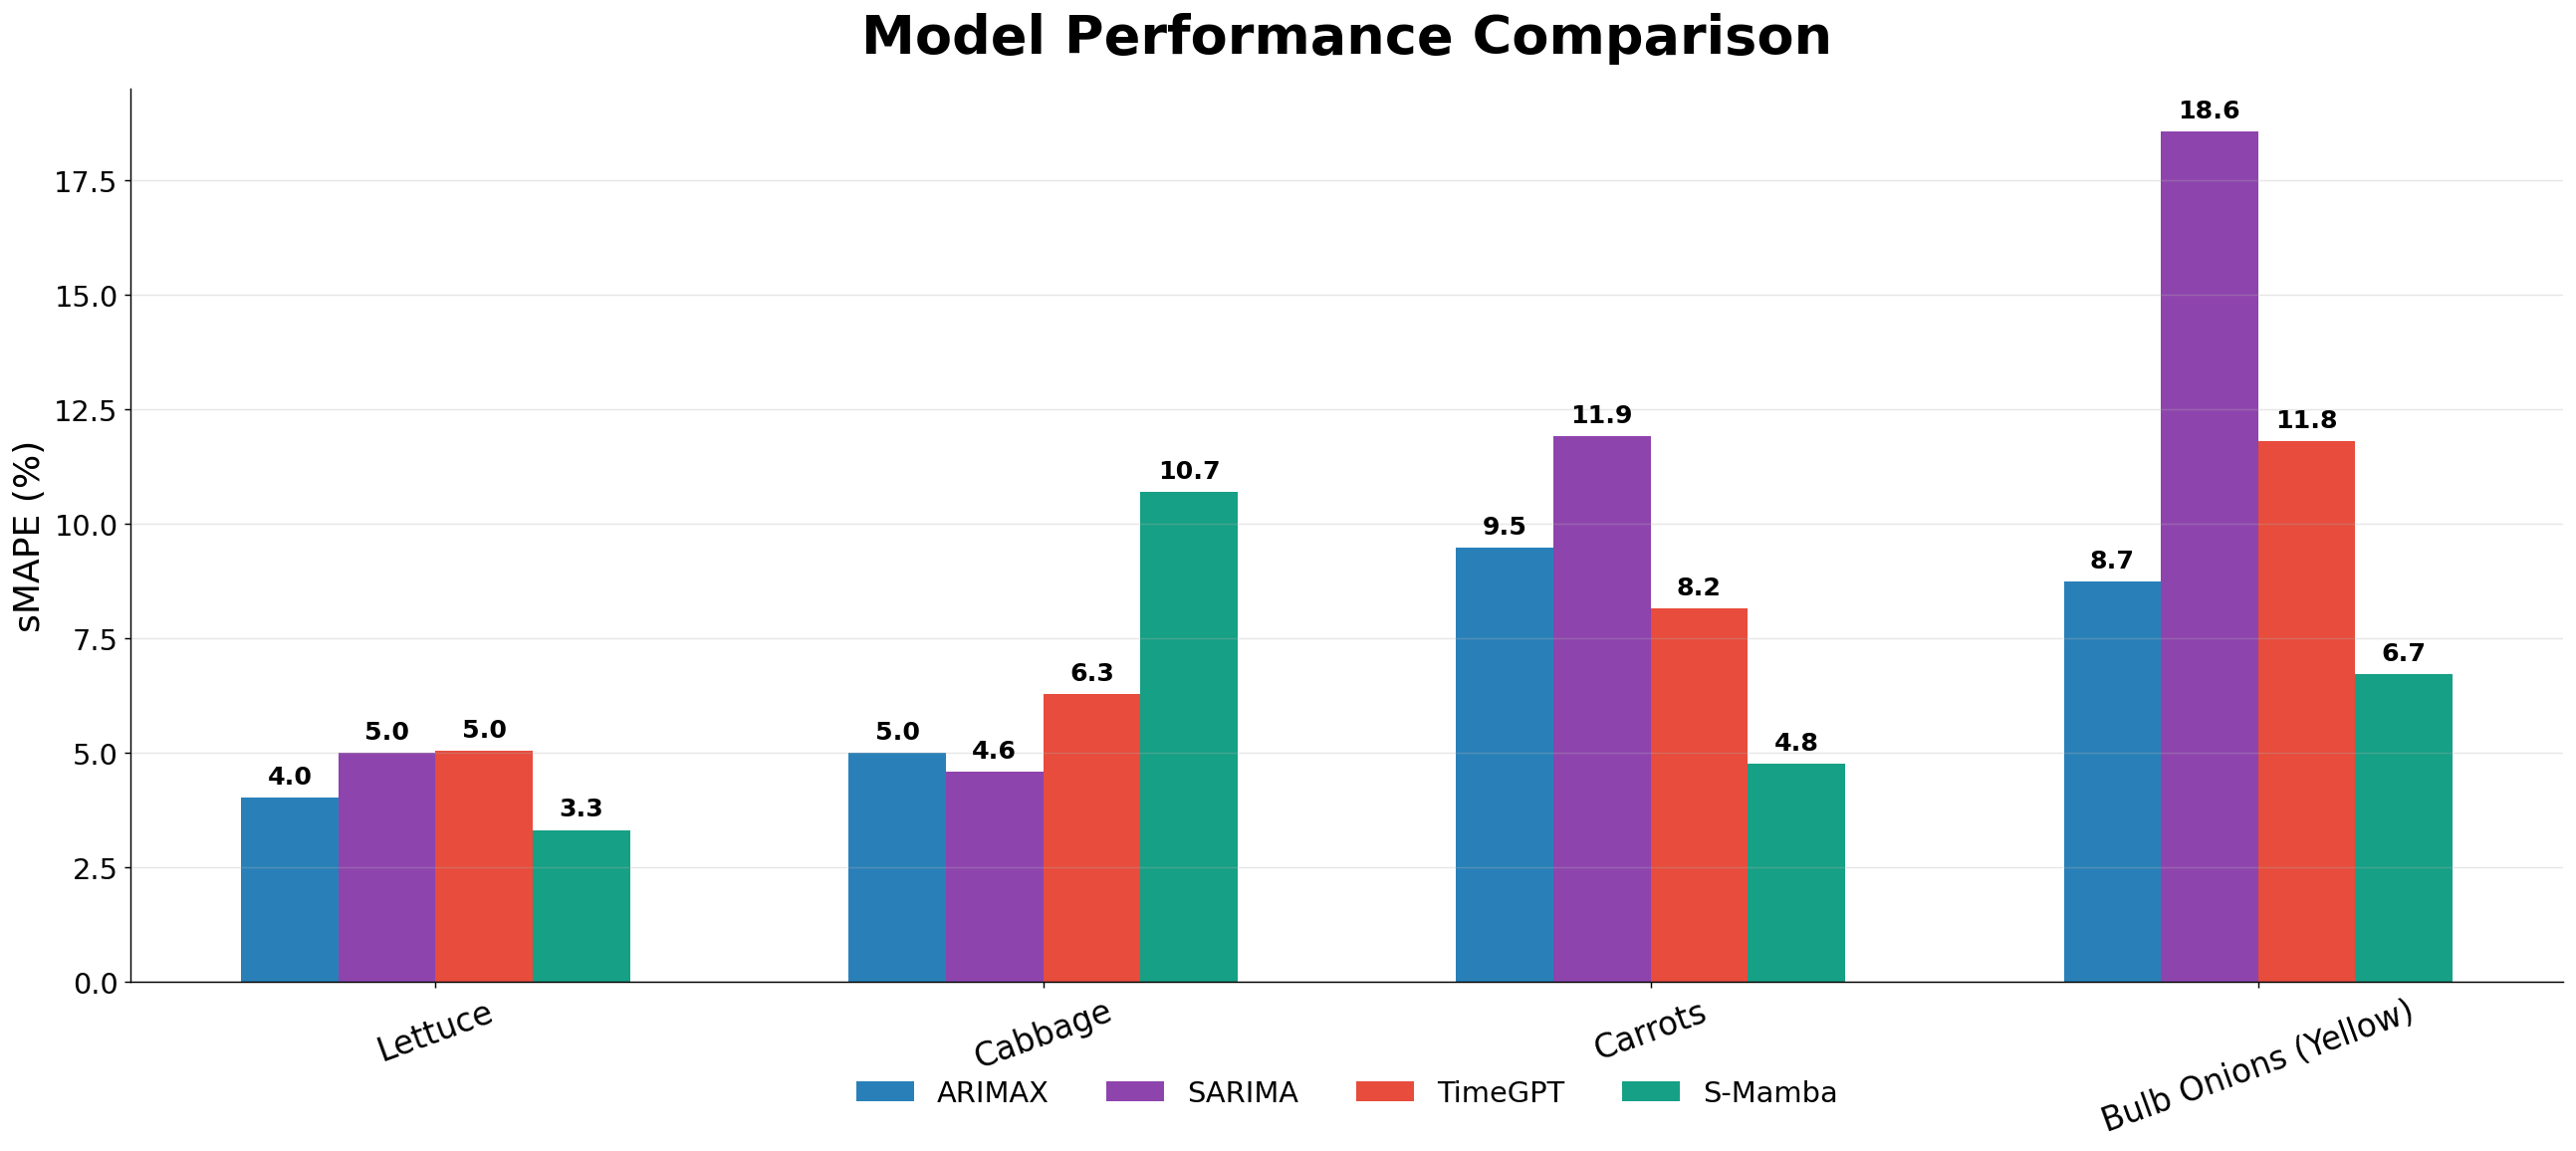

In [39]:

# ── Grouped sMAPE comparison chart ─────────────────────────────

ALL_COMMODITIES = ["Lettuce", "Cabbage", "Carrots", "Bulb Onions (Yellow)"]
EXCLUDE_MODELS  = {"Mamba"}

data = {}

for comm in ALL_COMMODITIES:
    comm_data = load_all(comm)
    if not comm_data:
        continue
    data[comm] = {model: smape(df["actual"], df["predicted"])
                  for model, df in comm_data.items()
                  if model not in EXCLUDE_MODELS}

models = list(next(iter(data.values())).keys())

x     = np.arange(len(ALL_COMMODITIES))
width = 0.16
offset = width * (len(models) - 1) / 2   # centre the group

fig, ax = plt.subplots(figsize=(20, 9))

for i, model in enumerate(models):
    values = [data[c].get(model, 0) for c in ALL_COMMODITIES]

    bars = ax.bar(
        x + i * width - offset,
        values,
        width,
        label=model,
        color=PALETTE[model]
    )

    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.2,
            f"{height:.1f}",
            ha="center", va="bottom",
            fontsize=14, fontweight="bold"
        )

ax.set_xticks(x)
ax.set_xticklabels(ALL_COMMODITIES, fontsize=18, rotation=20)
ax.set_ylabel("sMAPE (%)", fontsize=20)
ax.set_title("Model Performance Comparison", fontsize=30, fontweight="bold", pad=20)
ax.tick_params(axis="y", labelsize=16)
ax.legend(fontsize=16, loc="upper center", bbox_to_anchor=(0.5, -0.08),
          ncol=len(models), frameon=False)
ax.grid(axis="y", alpha=0.3)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()
